# DNA Fiber Assay Analysis

**Purpose:** Compare replication speed and inter-origin distance between WT and MGS variants.

**Author:** Elena Lopatukhina
**Date:** 2026-07-15

## Workflow
1. Parameters import
2. Data loading
3. Data propcessing
4. Basic statistics calculation
5. Processing outliers
6. Statistical analysis
7. Tables export
8. Graphs plot

# 1. Parameters

In [1]:
INPUT_DIR = "./examples/data"
OUTPUT_DIR = "./examples/results"

pixel_size = 0.16125 # µm
conversion_factor = 2.59 # kb/µm
time = 20 # minutes

# 2. Import data

## 2.1 Data loading

In [2]:
from utils import load_data, data_subset

data = load_data(dir = INPUT_DIR, pixel_size=pixel_size)

print(f"Total number of measurements for analysis is: {data.shape[0]}")

Total number of measurements for analysis is: 39


In [3]:
data.head()

,Sample_name,File,Measurement_type,Length,ROI,Path
0,None,HCl_1h15min_15o_2_-02_Interorigin_distance,Interorigin_distance,21.412387,0524-0356,./examples/data/HCl_1h15min_15o_2_-02/HCl_1h15...
1,None,HCl_1h15min_15o_2_-02_Interorigin_distance,Interorigin_distance,21.957574,0540-0471,./examples/data/HCl_1h15min_15o_2_-02/HCl_1h15...
2,None,HCl_1h15min_15o_2_-02_Interorigin_distance,Interorigin_distance,19.727003,0356-0632,./examples/data/HCl_1h15min_15o_2_-02/HCl_1h15...
3,None,siSCR_HaloEmpty-27_Fiber_length,Fiber_length,7.903669,0471-0717,./examples/data/siSCR_HaloEmpty-27/siSCR_HaloE...
4,None,siSCR_HaloEmpty-27_Fiber_length,Fiber_length,5.084535,0458-0675,./examples/data/siSCR_HaloEmpty-27/siSCR_HaloE...


### 2.2 Manually fill Sample_name column

In [4]:
# Create Sample name column empty (custom parsing of filenames)
data['Sample_name'] = data['File'].apply(lambda x: x.split("_")[1].split("-")[0])

data["Sample_name"] = data["Sample_name"].apply(
    lambda x: "WT" if "1h15min" in x else x
)

data["Sample_name"] = data["Sample_name"].apply(
    lambda x: "WT" if "30min" in x else x
)

mask = (
    (data["Sample_name"] == "HaloEmpty") &
    (data["File"].str.contains("siORC1_HaloEmpty", na=False))
)
data.loc[mask, "Sample_name"] = "siORC1"

# Update only rows where Sample_name == "HaloEmpty" and File contains "siSCR_HaloEmpty"
mask = (
    (data["Sample_name"] == "HaloEmpty") &
    (data["File"].str.contains("siSCR_HaloEmpty", na=False))
)

data.loc[mask, "Sample_name"] = "siSCR"

# Info about samples
sample_names = set(data["Sample_name"])
print(f"The amount of samples is: {len(sample_names)}.")
print(f"There are: {sample_names}")

The amount of samples is: 2.
There are: {'siSCR', 'WT'}


In [5]:
data.head()

,Sample_name,File,Measurement_type,Length,ROI,Path
0,WT,HCl_1h15min_15o_2_-02_Interorigin_distance,Interorigin_distance,21.412387,0524-0356,./examples/data/HCl_1h15min_15o_2_-02/HCl_1h15...
1,WT,HCl_1h15min_15o_2_-02_Interorigin_distance,Interorigin_distance,21.957574,0540-0471,./examples/data/HCl_1h15min_15o_2_-02/HCl_1h15...
2,WT,HCl_1h15min_15o_2_-02_Interorigin_distance,Interorigin_distance,19.727003,0356-0632,./examples/data/HCl_1h15min_15o_2_-02/HCl_1h15...
3,siSCR,siSCR_HaloEmpty-27_Fiber_length,Fiber_length,7.903669,0471-0717,./examples/data/siSCR_HaloEmpty-27/siSCR_HaloE...
4,siSCR,siSCR_HaloEmpty-27_Fiber_length,Fiber_length,5.084535,0458-0675,./examples/data/siSCR_HaloEmpty-27/siSCR_HaloE...


### 2.3 Split data into replication speed and IOD dataframe

In [6]:
speed = data_subset(df = data, measurement_type = 'Fiber_length')
print(f"The total amount of fibers measurements is: {speed.shape[0]}")

iod = data_subset(df = data, measurement_type = 'Interorigin_distance')
print(f"The total amount of IOD measurements is: {iod.shape[0]}")

The total amount of fibers measurements is: 30
The total amount of IOD measurements is: 9


### 2.4 Checking the number of measurements for each sample

#### 2.4.1 Replication speed
Divide this number by 2 because these are green and red tracks separately.

In [7]:
speed.groupby('Sample_name')['File'].count()

Sample_name
WT       14
siSCR    16
Name: File, dtype: int64

In [8]:
# OPTIONAL
# Check analized files
#sample_name = "MGS5"
#speed[speed["Sample_name"] == sample_name]['File'].value_counts()

#### 2.4.2. IOD

In [9]:
iod.groupby('Sample_name')['File'].count()

Sample_name
WT       5
siSCR    4
Name: File, dtype: int64

In [10]:
# OPTIONAL
# Check analized files
#sample_name = "siORC1"
#iod[iod["Sample_name"] == sample_name]['File'].value_counts()

# 3. Data processing

In [11]:
from utils import speed_processing, iod_processing

replication_speed = speed_processing(df = speed, conversion_factor = conversion_factor, time = time)
iod_kb = iod_processing(df = iod, conversion_factor = conversion_factor)

All files contain an even number of fibers.


In [12]:
replication_speed.head()

,Sample_name,File,Speed_kb_min,ROI,Path
0,WT,HCl_1h15min_15o_2__Fiber_length,1.679654,"[0845-0283, 0814-0314]",./examples/data/HCl_1h15min_15o_2_/HCl_1h15min...
1,WT,HCl_1h15min_15o_2__Fiber_length,1.681221,"[0378-0765, 0414-0739]",./examples/data/HCl_1h15min_15o_2_/HCl_1h15min...
2,WT,HCl_1h15min_15o_2__Fiber_length,1.425084,"[0521-0655, 0494-0676]",./examples/data/HCl_1h15min_15o_2_/HCl_1h15min...
3,WT,HCl_1h15min_15o_Fiber_length,2.396300,"[0464-0881, 0495-0819]",./examples/data/HCl_1h15min_15o/HCl_1h15min_15...
4,WT,HCl_1h15min_15o_Fiber_length,1.533001,"[0464-0300, 0448-0336]",./examples/data/HCl_1h15min_15o/HCl_1h15min_15...


In [13]:
iod_kb.head()

,Sample_name,File,IOD_kb,ROI,Path
0,WT,HCl_1h15min_15o_2_-02_Interorigin_distance,55.458084,0524-0356,./examples/data/HCl_1h15min_15o_2_-02/HCl_1h15...
1,WT,HCl_1h15min_15o_2_-02_Interorigin_distance,56.870116,0540-0471,./examples/data/HCl_1h15min_15o_2_-02/HCl_1h15...
2,WT,HCl_1h15min_15o_2_-02_Interorigin_distance,51.092936,0356-0632,./examples/data/HCl_1h15min_15o_2_-02/HCl_1h15...
13,siSCR,siSCR_HaloEmpty-26_Interorigin_distance,41.557019,0744-0092,./examples/data/siSCR_HaloEmpty-26/siSCR_HaloE...
14,siSCR,siSCR_HaloEmpty-26_Interorigin_distance,37.689279,0758-0283,./examples/data/siSCR_HaloEmpty-26/siSCR_HaloE...


# 4. Basic statistics calculation

In [14]:
from utils import description_stats

stats_speed = description_stats(replication_speed, col = "Speed_kb_min")
stats_iod = description_stats(iod_kb, col = "IOD_kb")

In [15]:
stats_speed

,Count,Mean,Median,SD
Sample_name,,,,
WT,7,1.716857,1.679654,0.318909
siSCR,8,1.742989,1.733415,0.466374


In [16]:
stats_iod

,Count,Mean,Median,SD
Sample_name,,,,
WT,5,47.869276,51.092936,10.248470
siSCR,4,43.464788,43.106037,5.182406


# 5. Processing outliers

In [17]:
from utils import outliers

speed_outliers = outliers(df = replication_speed, col = 'Speed_kb_min')
iod_outliers = outliers(df = iod_kb, col = 'IOD_kb')

In [18]:
speed_outliers

,Sample_name,File,Speed_kb_min,ROI,Path


In [19]:
iod_outliers

,Sample_name,File,IOD_kb,ROI,Path


# 6. Statistical analysis
Mann-Whetney test (U-test)

In [20]:
from utils import u_test

u_speed = u_test(df = replication_speed, col = "Speed_kb_min", control_sample = "WT")
u_iod = u_test(df = iod_kb, col = "IOD_kb", control_sample = "WT")

In [21]:
u_speed

,Group_1,Group_2,Group_1_n,Group_2_n,U,p-value
0,WT,siSCR,7,8,24.0,0.694328


In [22]:
u_iod

,Group_1,Group_2,Group_1_n,Group_2_n,U,p-value
0,WT,siSCR,5,4,14.0,0.412698


# 7. Tables export

In [23]:
from utils import table_export


# Export of tables with processed results
table_export(df = replication_speed, dir = OUTPUT_DIR, filename = "replication_speed.xlsx")
table_export(df = iod_kb, dir = OUTPUT_DIR, filename = "iod_kb.xlsx")

# Export of tables with descriptive statistics
table_export(df = stats_speed, dir = OUTPUT_DIR, filename = "replication_speed_description.xlsx")
table_export(df = stats_iod, dir = OUTPUT_DIR, filename = "iod_description.xlsx")

# Export of tables with U-test analysis
table_export(df = u_speed, dir = OUTPUT_DIR, filename = "u_speed.xlsx")
table_export(df = u_iod, dir = OUTPUT_DIR, filename = "u_iod.xlsx")

# 8. Graphs with statistics

In [24]:
from plotting import boxplot_with_statistics

Plot saved to: ./examples/results/speed.png


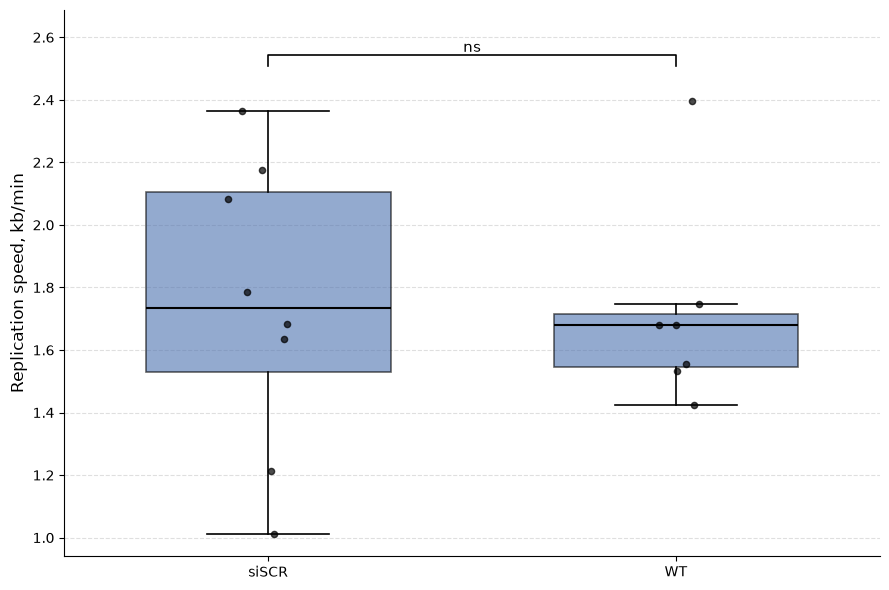

In [25]:
boxplot_with_statistics(data_plot = replication_speed,
                            sample_order = ['siSCR', 'WT'],
                            var = 'Speed_kb_min',
                            stats_plot = u_speed,
                            y_axis = "Replication speed, kb/min",
                            save_dir = OUTPUT_DIR,
                            save_name = "speed",
                            ext = "png")

Plot saved to: ./examples/results/iod.png


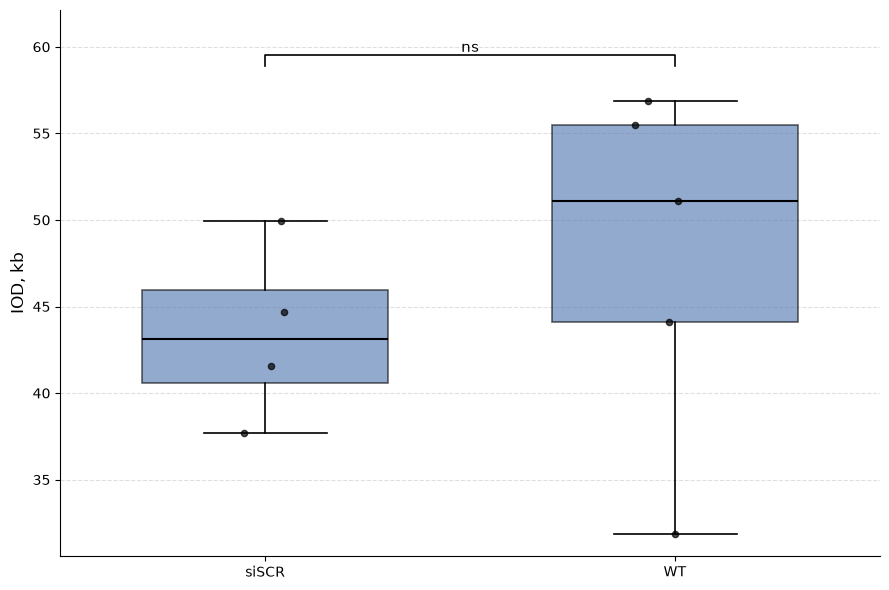

In [26]:
boxplot_with_statistics(data_plot = iod_kb,
                            sample_order = ['siSCR', 'WT'],
                            var = 'IOD_kb',
                            stats_plot = u_iod,
                            y_axis = "IOD, kb",
                            save_dir = OUTPUT_DIR,
                            save_name = "iod",
                            ext = "png")

### *Optional code*

In [27]:
# -------------------------------------------------------
# t-test data analysis
# -------------------------------------------------------

# Data
# data_plot = iod_kb
# var = "IOD_kb"

# wt = data_plot.loc[
    # data_plot["Sample_name"] == "WT",
    # var
# ].dropna()

# results = []

# for sample in ["siSCR", "siORC1", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]:

    # mutant = data_plot.loc[
        # data_plot["Sample_name"] == sample,
        # var
    # ].dropna()

    # stat, p = ttest_ind(
        # wt,
        # mutant,
        # equal_var=False,   # Welch's t-test (recommended)
    # )

    # results.append({
        # "Comparison": f"WT vs {sample}",
        # "WT_n": len(wt),
        # "Sample_n": len(mutant),
        # "U": stat,
        # "p-value": p,
    # })

# stats_t_df = pd.DataFrame(results)

# print(stats_t_df)

In [28]:
# -------------------------------------------------------
# Boxplot without statistical brackets
# -------------------------------------------------------

# plt.figure(figsize=(7, 5))

# Variables
# data_plot = iod_kb
# var = "IOD_kb"

# Order of groups (optional)
# sample_order = ["siSCR", "siORC1", "WT", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]

# groups = []
# labels = []

# for sample in sample_order:
        # values = data_plot.loc[
        # data_plot["Sample_name"] == sample,
        # var
    # ]
        
        # groups.append(values)
        # labels.append(sample)

    

# bp = plt.boxplot(
    # groups,
    # patch_artist=True,
    # showfliers=False,
    # widths=0.6,
# )

# for box in bp["boxes"]:
    # box.set(facecolor="#4C72B0", alpha=0.6)

# Jittered dots
# for i, values in enumerate(groups, start=1):
    # x = np.random.normal(i, 0.05, len(values))
    # plt.scatter(x, values, s=20, color="black", alpha=0.7, zorder=3)

# plt.ylabel("iod_kb")
# plt.xticks(range(1, len(labels) + 1), labels)
# plt.grid(axis="y", linestyle="--", alpha=0.4)

# plt.tight_layout()
# plt.savefig(f"{OUTPUT_DIR}/iod_boxplot.png", dpi=600, bbox_inches="tight")
# print(f"Plot is saved in the directory: {OUTPUT_DIR}")

# plt.show()